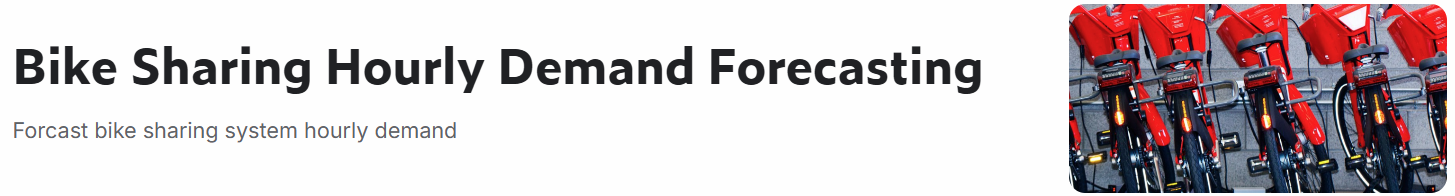
* kaggle : https://www.kaggle.com/competitions/bike-sharing-demand

<pre>datetime - hourly date + timestamp  
season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
holiday - whether the day is considered a holiday
workingday - whether the day is neither a weekend nor holiday
weather - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
          2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
          3: Light Snow, Light Rain + Thunderstorm + Scattered clouds...
          4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
temp - temperature in Celsius
atemp - "feels like" temperature in Celsius
humidity - relative humidity
windspeed - wind speed
casual - number of non-registered user rentals initiated
registered - number of registered user rentals initiated
count - number of total rentals

In [1]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


from sklearn.model_selection import train_test_split   #---- 문제답 분리
from sklearn.linear_model import LinearRegression, Ridge,Lasso  #---- 회귀모델(선형모델)
from sklearn.ensemble import RandomForestRegressor              #---- 회귀모델(트리모델)
   

from sklearn.metrics import mean_squared_error, root_mean_squared_log_error         #---- 평가 메트릭스
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler #----정규화(스케일링)
from sklearn.decomposition import PCA                  #---- 차원축소

# **[1] Data Load**

In [2]:
train = pd.read_csv("../datas/bike/train.csv", parse_dates=['datetime'])
test  = pd.read_csv("../datas/bike/test.csv" , parse_dates=['datetime'])
sub   = pd.read_csv("../datas/bike/sampleSubmission.csv")

In [3]:
train.shape, test.shape, sub.shape

((10886, 12), (6493, 9), (6493, 2))

In [4]:
train.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


In [5]:
test.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [6]:
sub.head(2)

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[us]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 456.7 KB


* <font color=red><b>결측없다
* <font color=red><b>글자있다 --> datetime --> 년월일시로 분리

## 년월일시 분리

In [9]:
train['yy']   = train['datetime'].dt.year
train['mm']   = train['datetime'].dt.month
train['dd']   = train['datetime'].dt.day
train['hh']   = train['datetime'].dt.hour
train['week'] = train['datetime'].dt.weekday #월요일~일요일  : 0~6

test['yy']   = test['datetime'].dt.year
test['mm']   = test['datetime'].dt.month
test['dd']   = test['datetime'].dt.day
test['hh']   = test['datetime'].dt.hour
test['week'] = test['datetime'].dt.weekday

In [10]:
train = train.set_index("datetime")
test  = test.set_index("datetime")

In [11]:
train.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5


In [12]:
test.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week
datetime,,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3


In [13]:
# test = test.reset_index()            #-------------- 인덱스로 넣기
# test.head(2)
# test  = test.set_index("datetime")   #-------------- 인덱스를 빼기
# test.head(2)

In [14]:
sub.head(5)

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


# **[2] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도(왜도,첨도,정규분포)

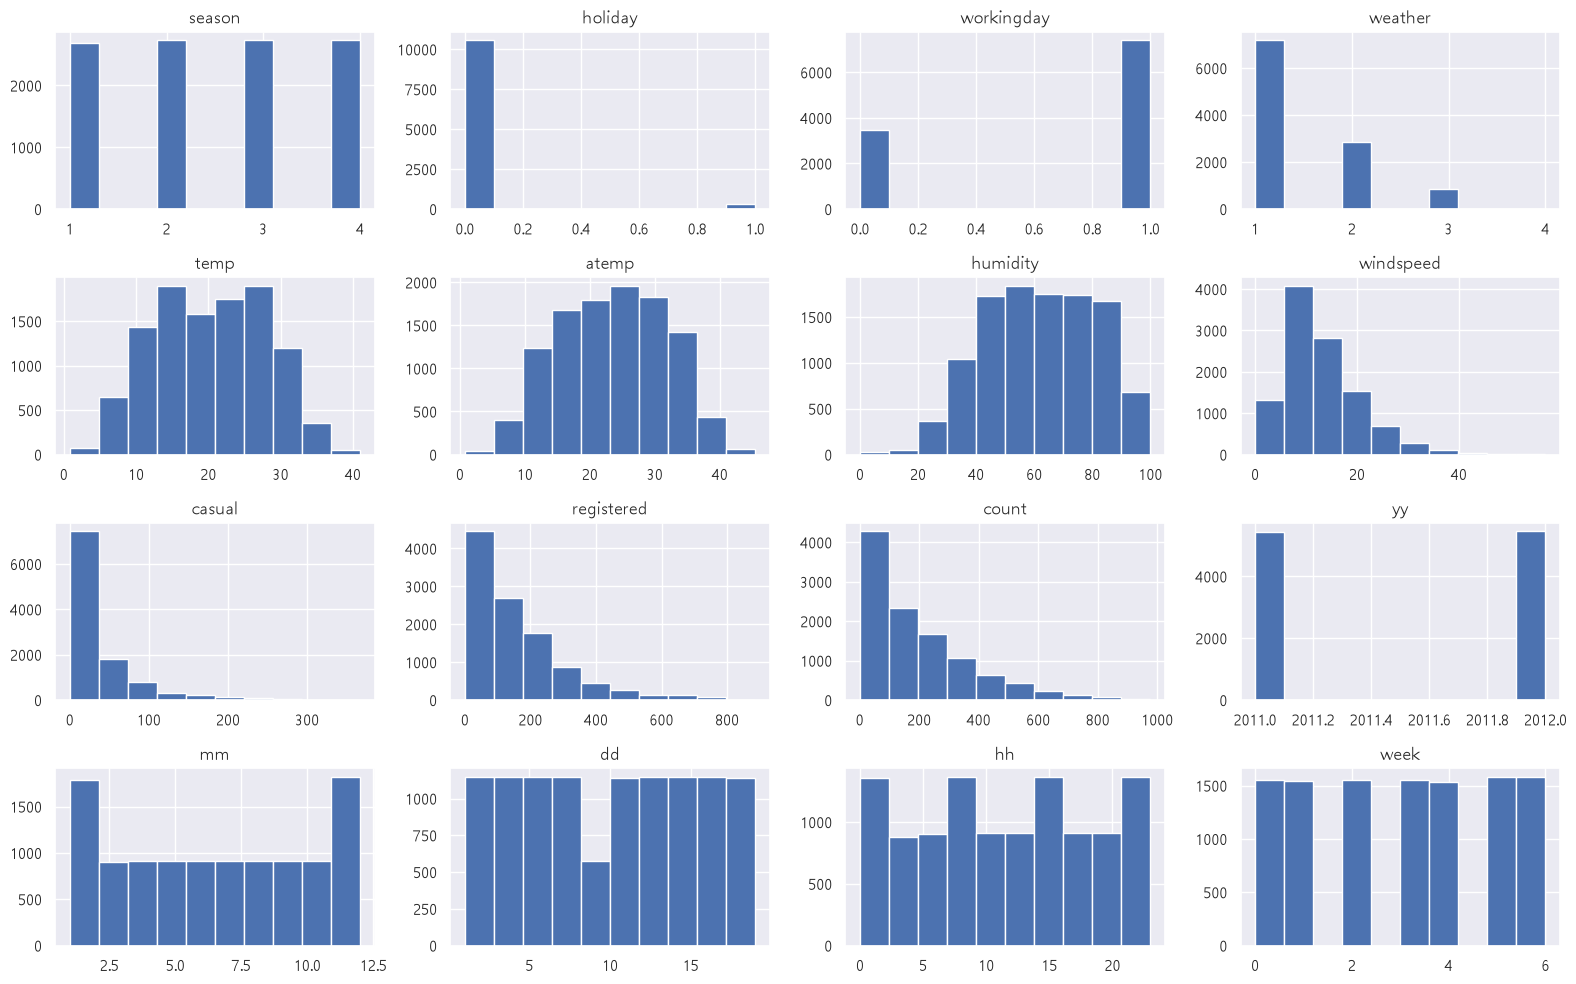

In [15]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

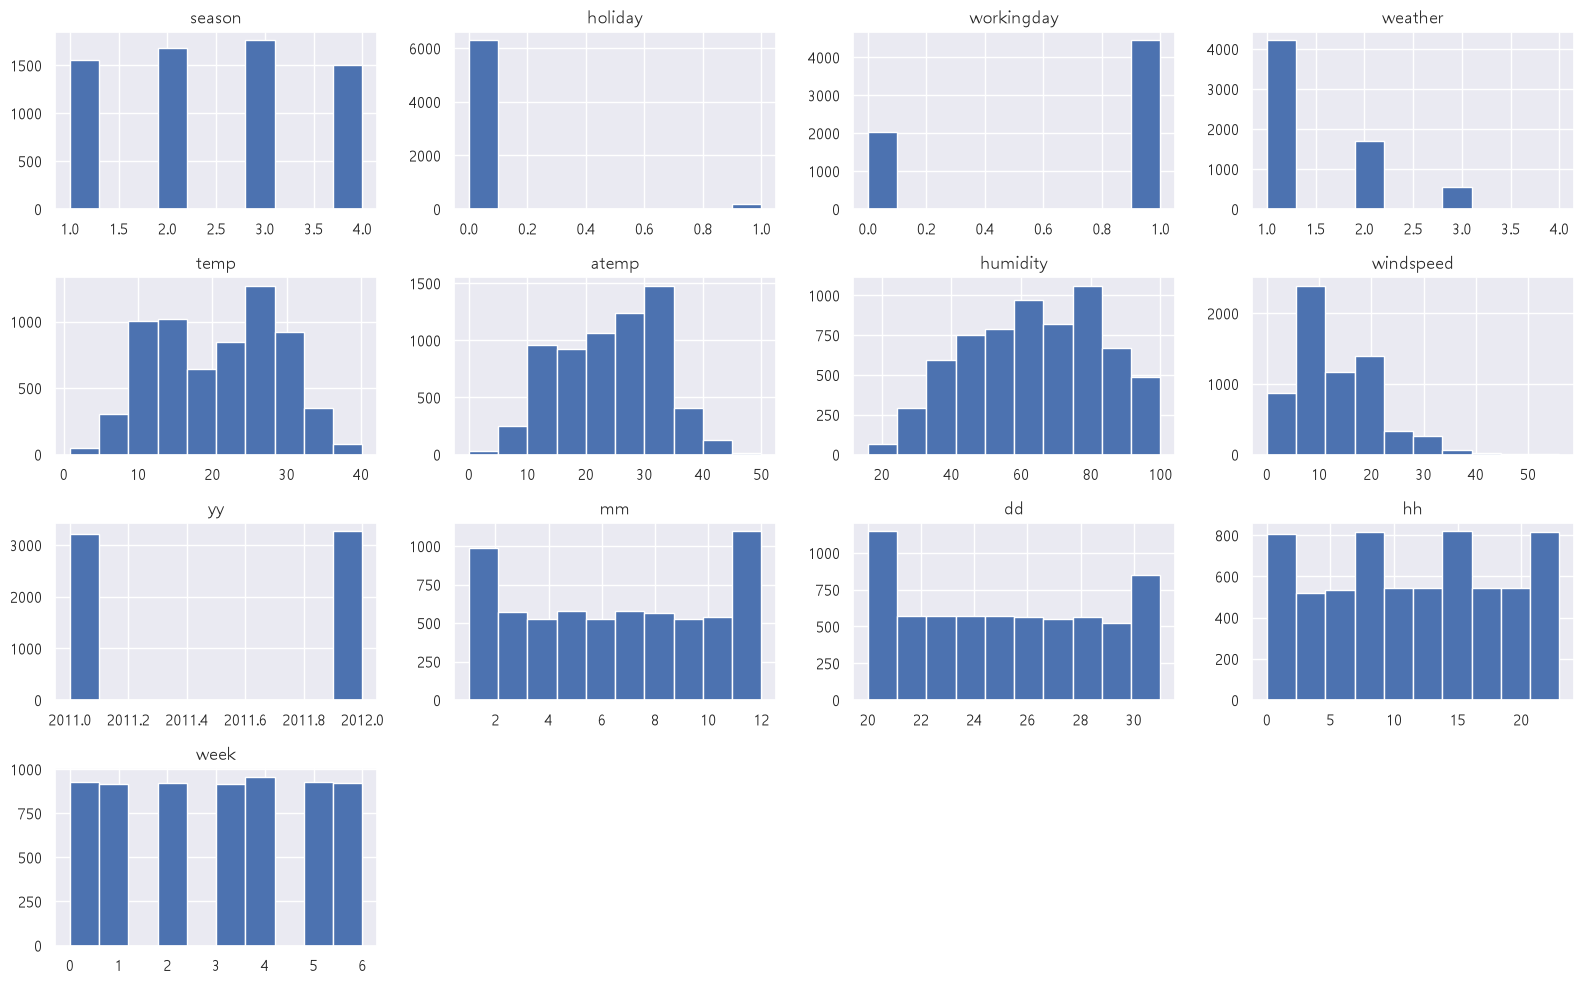

In [16]:
test.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

## ['dd'] 컬럼 삭제

* <font color=red><b>train['dd'] 1 ~20일
* <font color=red><b>test['dd']  21 ~ 말일
* <font color=red><b>['dd'] 컬럼 삭제

In [17]:
#train = train.drop(columns=["dd"])    #---칸지우기

train = train.drop(['dd'], axis=1)    #---칸지우기
test  = test.drop(['dd'], axis=1)    #---칸지우기

In [18]:
test.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week
datetime,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,0,3
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,1,3


## **상관분석**

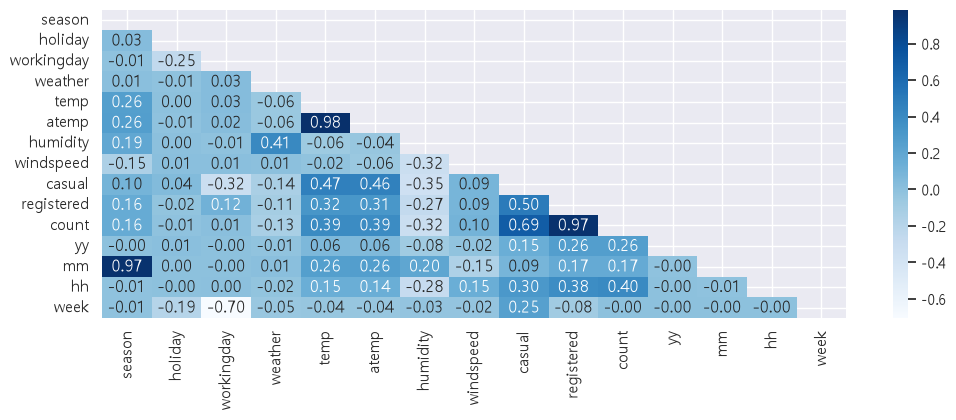

In [19]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

* mm - season : 0.97  ----------------------- 다중공선 - 필요시 파생피쳐는 삭제
* week - workingday : -0.70  ---------------- 다중공선 - 필요시 파생피쳐는 삭제
* atemp - temp : 0.98  --> 대여수 영향 큼
* casual + registered = count : 0.97

<pre>
- 날짜 : 'yy', 'mm', 'hh', 'season'
- 날씨 : 'weather', 'temp', 'atemp','humidity', 'windspeed'
- 타켓 : 'casual', 'registered', 'count' 
- 휴일 : 'holiday', 'workingday', 'week'

## 날짜 관련
* 계절 : 'yy', 'mm', 'hh', 'season'

### 년별, 월별, 시간별, 계절별 대여수

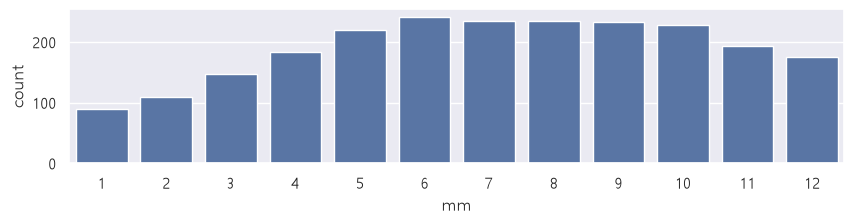

In [20]:
plt.figure(figsize=(10, 2))
sns.barplot(x="mm", y="count", data=train, errorbar=None)  #errorbar=('ci', 95)
plt.show()

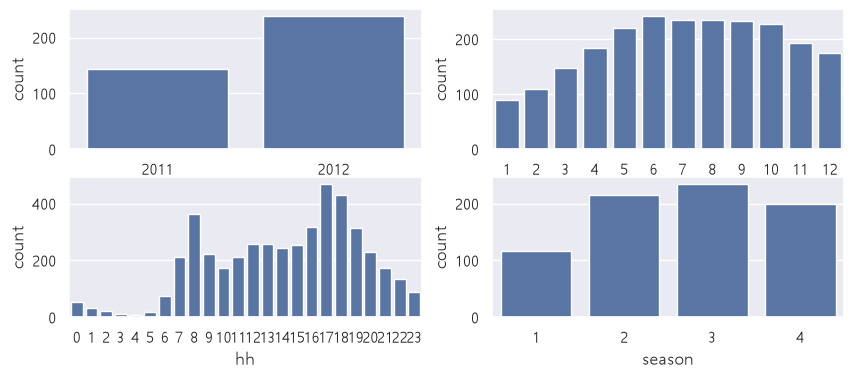

In [21]:
plt.figure(figsize=(10, 4)) 

plt.subplot(2,2,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="yy", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="mm", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="hh", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      4)         #---------------------------2행2열의 4번째
sns.barplot(x="season", y="count", data=train, errorbar=None) 

plt.show()

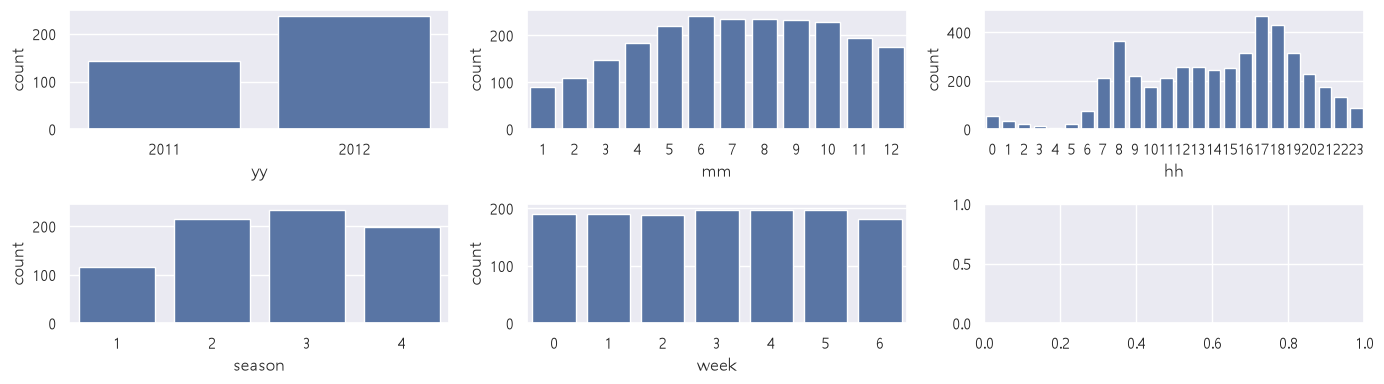

In [22]:
fig, axes = plt.subplots(2,3,     figsize=(14, 4)) 
col_list=['yy', 'mm', 'hh', 'season', 'week']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.barplot(x=col, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

In [23]:
train.groupby(['mm'])['mm'].sum()

mm
1       884
2      1802
3      2703
4      3636
5      4560
6      5472
7      6384
8      7296
9      8181
10     9110
11    10021
12    10944
Name: mm, dtype: int32

## 날씨 관련 
* 'weather', 'temp', 'atemp','humidity', 'windspeed'

### <font color=red><b>★★for문 이용한 차트 출력★★</b>

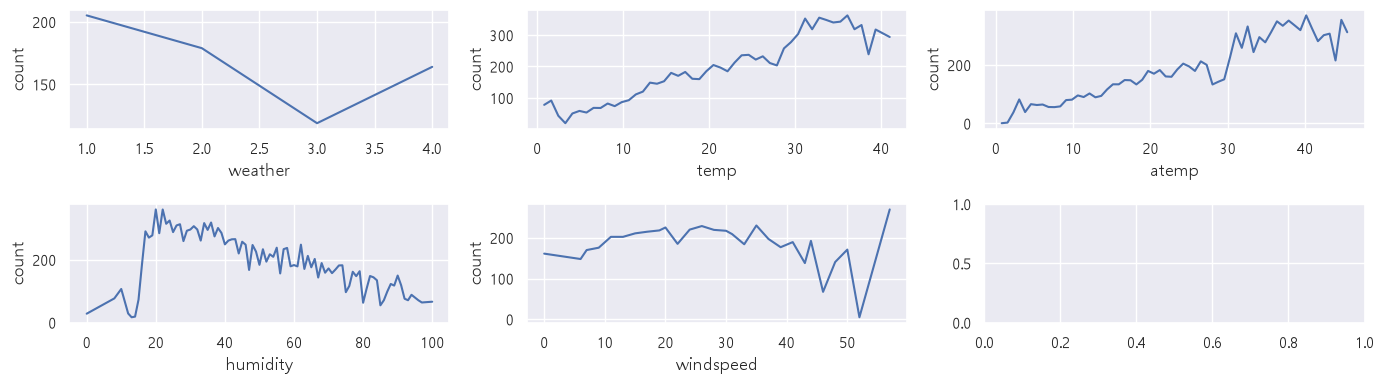

In [24]:
fig, axes = plt.subplots(2,3,     figsize=(14, 4)) 
col_list=['weather', 'temp', 'atemp','humidity', 'windspeed']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.lineplot(x=col, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

### temp

* 시간별 온도/대여수 멀티 차트
* 라인:평균온도 / 막대(대여수)

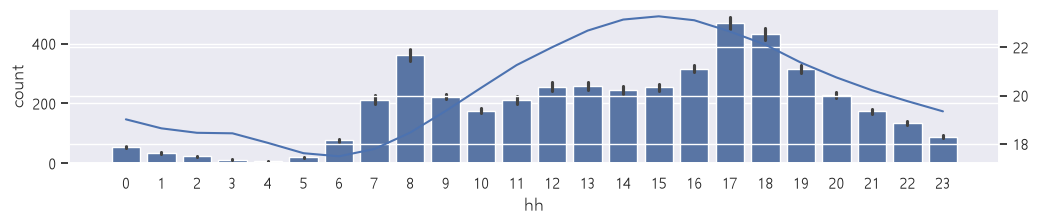

In [25]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

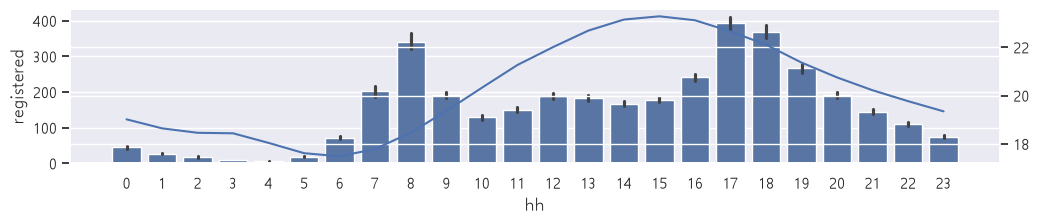

In [26]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

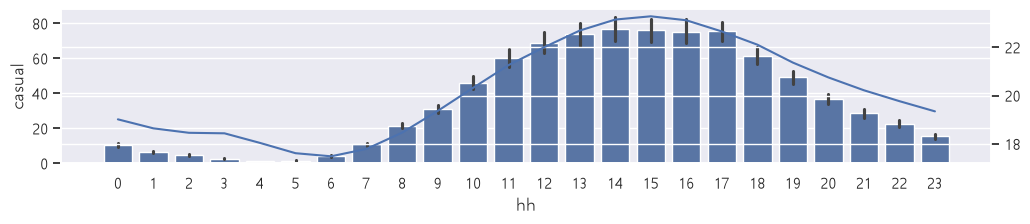

In [27]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

* <font color=red><b>현장 대여수(casual)는 온도(temp)만 보고도 예측 가능

### humidity
* 라인:습도평균 / 막대:대여수

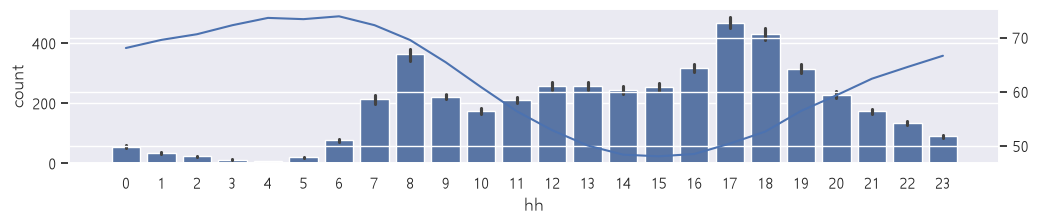

In [28]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

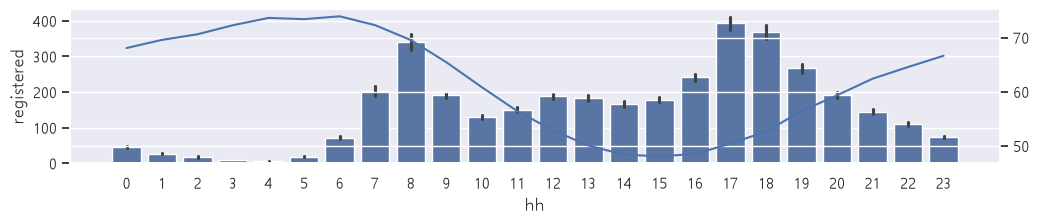

In [29]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

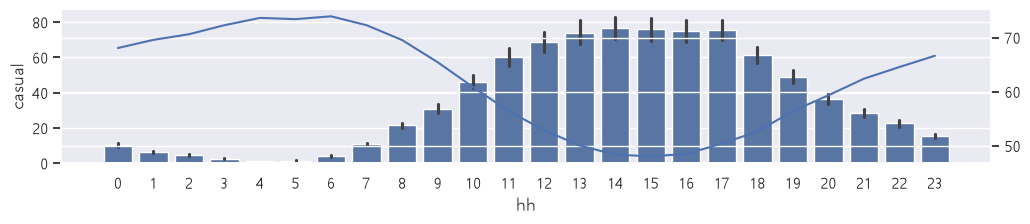

In [30]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

### windspeed
* 라인:풍속평균 / 막대:대여수

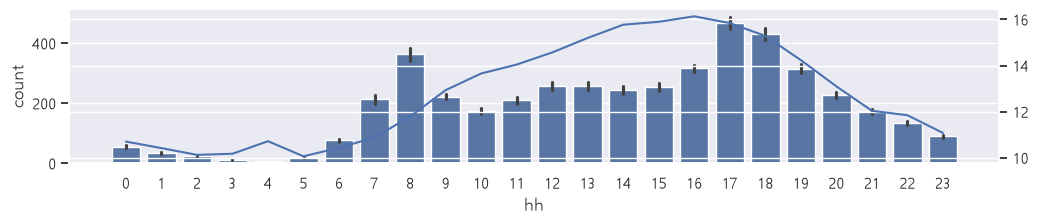

In [31]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

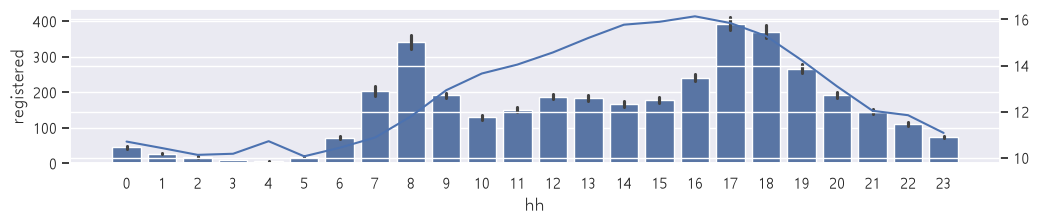

In [32]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

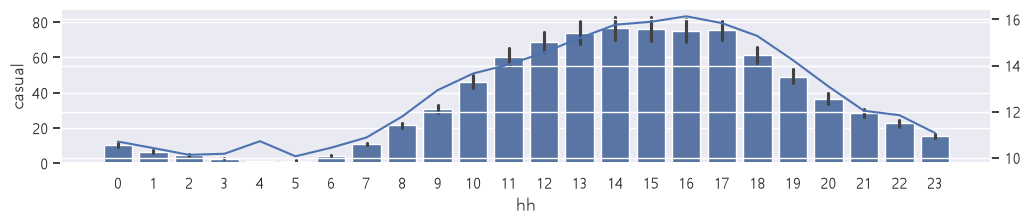

In [33]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

* <font color=red><b>현장 대여수(casual)는 풍속(windspeed)만 보고도 예측 가능

### weather
* 라인: / 막대:대여수

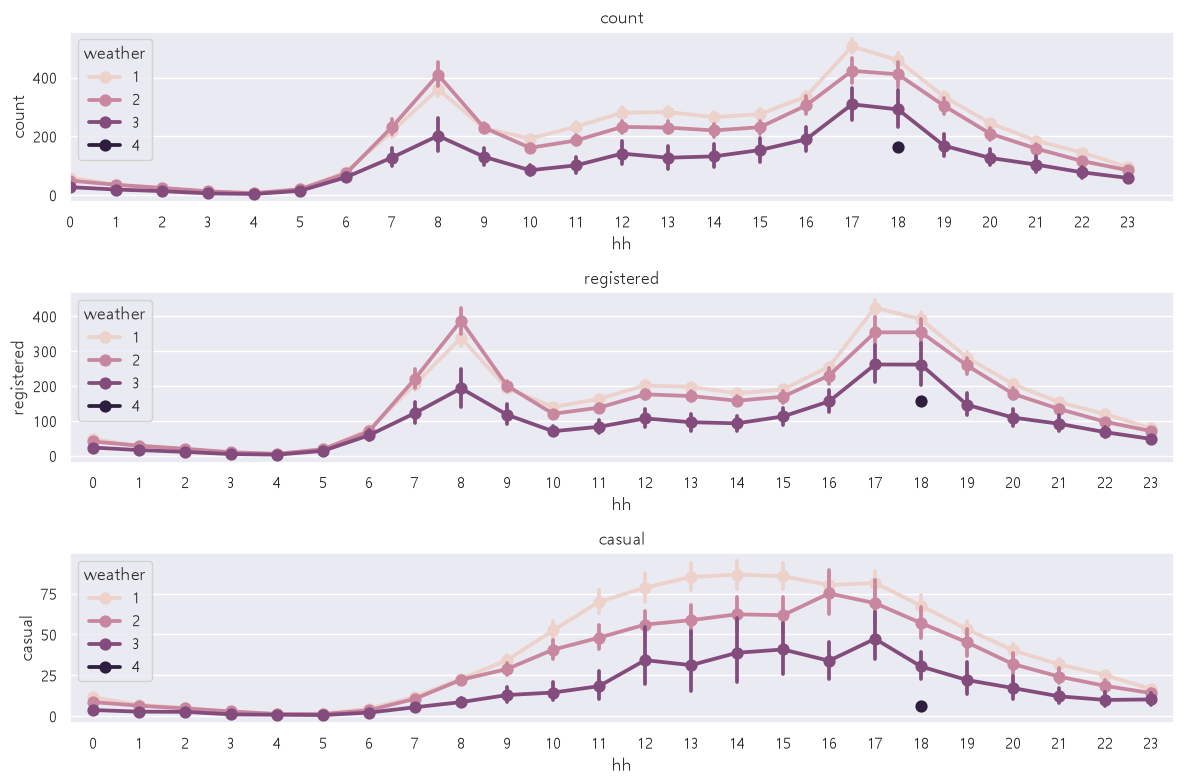

In [34]:
fig,ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8))
sns.pointplot(data=train, x='hh', y='count'    , hue='weather', ax=ax[0])
ax[0].set(xlim=(0, 24))
ax[0].set(title="count")

sns.pointplot(data=train, x='hh', y='registered', hue='weather', ax=ax[1])
ax[1].set(title="registered")

sns.pointplot(data=train, x='hh', y='casual'    , hue='weather', ax=ax[2])
ax[2].set(title="casual")

plt.tight_layout()
plt.show()

* <font color=red><b>weather == 3 인경우 count 이상??

## 타켓 : 'count'(총), 'registered'(예약), 'casual'(현장)

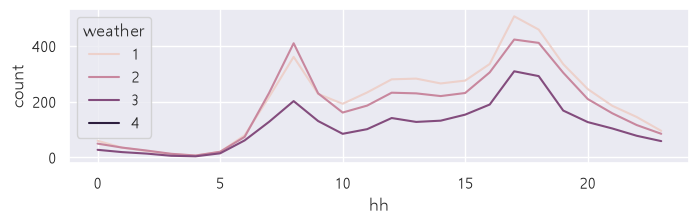

In [35]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
plt.show()

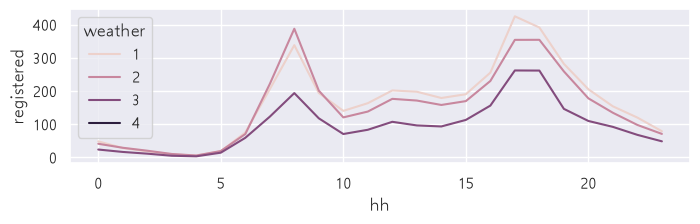

In [36]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="registered", hue="weather", data=train, errorbar=None)
plt.show()

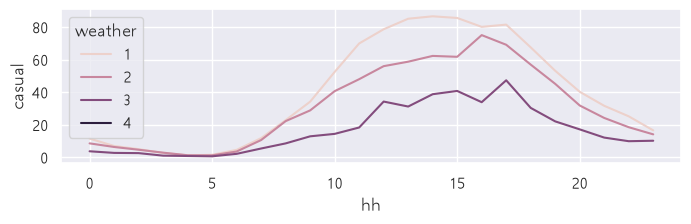

In [37]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="casual", hue="weather", data=train, errorbar=None)
plt.show()

In [38]:
# train[ㅈ][ㅋ]
train[ train['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week
datetime,,,,,,,,,,,,,,,
2012-01-09 18:00:00,1,0,1,4,8.2,11.365,86,6.0032,6,158,164,2012,1,18,0


In [39]:
test[ test['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week
datetime,,,,,,,,,,,,
2011-01-26 16:00:00,1,0,1,4,9.02,9.85,93,22.0028,2011,1,16,2
2012-01-21 01:00:00,1,0,0,4,5.74,6.82,86,12.9980,2012,1,1,5


## 주말/휴일 관련
* 'holiday', 'workingday', 'week'

In [40]:
train[['holiday', 'workingday']].value_counts()

holiday  workingday
0        1             7412
         0             3163
1        0              311
Name: count, dtype: int64

In [41]:
train['day_type'] = 0
train.loc[  (train['holiday'] ==0) &  (train['workingday']==1) , 'day_type']  = 0     # 0

#holiday ==0  workingday==0
train.loc[  (train['holiday'] ==0) &  (train['workingday']==0) , 'day_type']  = 1     # 1

#holiday ==1  workingday==0
train.loc[  (train['holiday'] ==1) &  (train['workingday']==0) , 'day_type']  = 2      # 2

train['day_type'].value_counts()

day_type
0    7412
1    3163
2     311
Name: count, dtype: int64

In [42]:
test['day_type'] = 0
test.loc[  (test['holiday'] ==0) &  (test['workingday']==1) , 'day_type']  = 0     # 0

#holiday ==0  workingday==0
test.loc[  (test['holiday'] ==0) &  (test['workingday']==0) , 'day_type']  = 1     # 1

#holiday ==1  workingday==0
test.loc[  (test['holiday'] ==1) &  (test['workingday']==0) , 'day_type']  = 2      # 2

test['day_type'].value_counts()

day_type
0    4453
1    1851
2     189
Name: count, dtype: int64

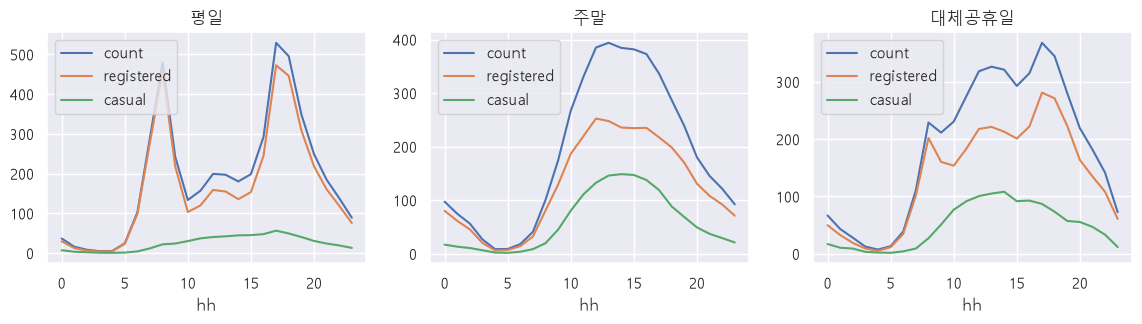

In [43]:
# plt.figure(figsize=(8,2))
# sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
# plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3,     figsize=(14, 3)) 

g0 = train[ train['day_type']==0 ].groupby('hh')[['count','registered','casual']].mean()
g0.plot(ax=ax1, title='평일') 

g1 = train[ train['day_type']==1 ].groupby('hh')[['count','registered','casual']].mean()
g1.plot(ax=ax2, title='주말') 

g2 = train[ train['day_type']==2 ].groupby('hh')[['count','registered','casual']].mean()
g2.plot(ax=ax3, title='대체공휴일') 

plt.show()


## 요일/월(파생피쳐) 별 대여수

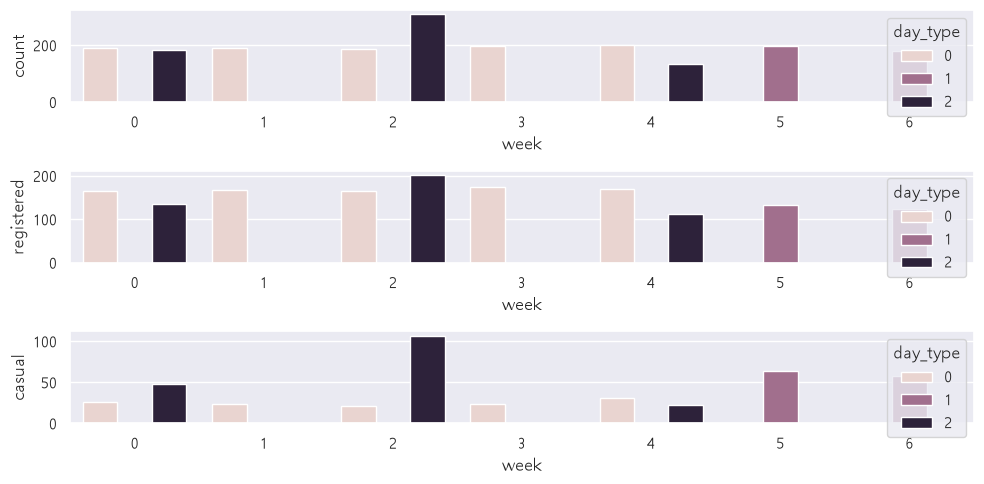

In [44]:
plt.figure(figsize=(10, 5)) 

plt.subplot(3,1,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="week", y="count"     , hue="day_type", data=train, errorbar=None) 

plt.subplot(3,1,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="week", y="registered", hue="day_type",data=train, errorbar=None) 

plt.subplot(3,1,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="week", y="casual"    , hue="day_type", data=train, errorbar=None) 

plt.tight_layout()
plt.show()

* <FONT COLOR=RED><B>2012년 7월 4일 수요일: 미국 독립기념일 불꽃놀이 대규모 축제
* <FONT COLOR=RED><B>2012년 10월 22일 ~ 11월 2일 : 허리케인 샌디

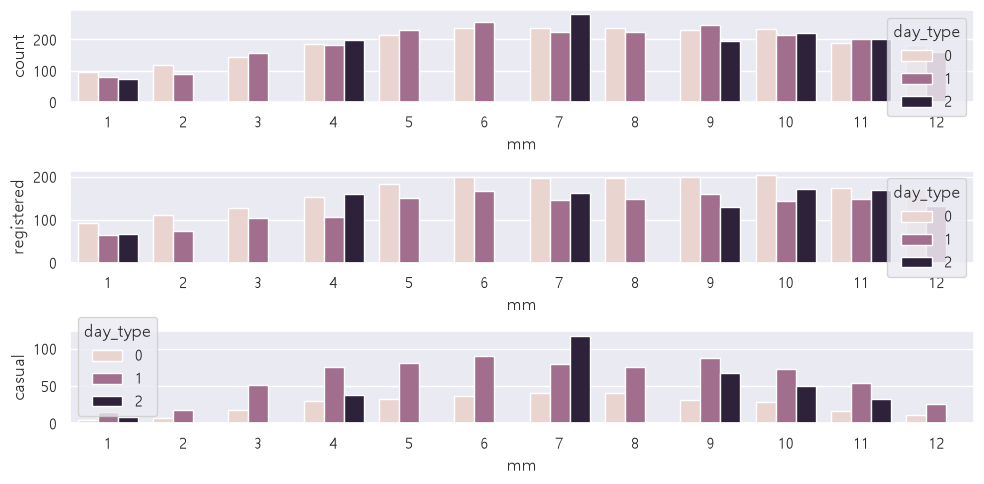

In [45]:
plt.figure(figsize=(10, 5)) 

plt.subplot(3,1,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="mm", y="count"     , hue="day_type", data=train, errorbar=None) 

plt.subplot(3,1,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="mm", y="registered", hue="day_type",data=train, errorbar=None) 

plt.subplot(3,1,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="mm", y="casual"    , hue="day_type", data=train, errorbar=None) 

plt.tight_layout()
plt.show()

## 이상치(outlier)

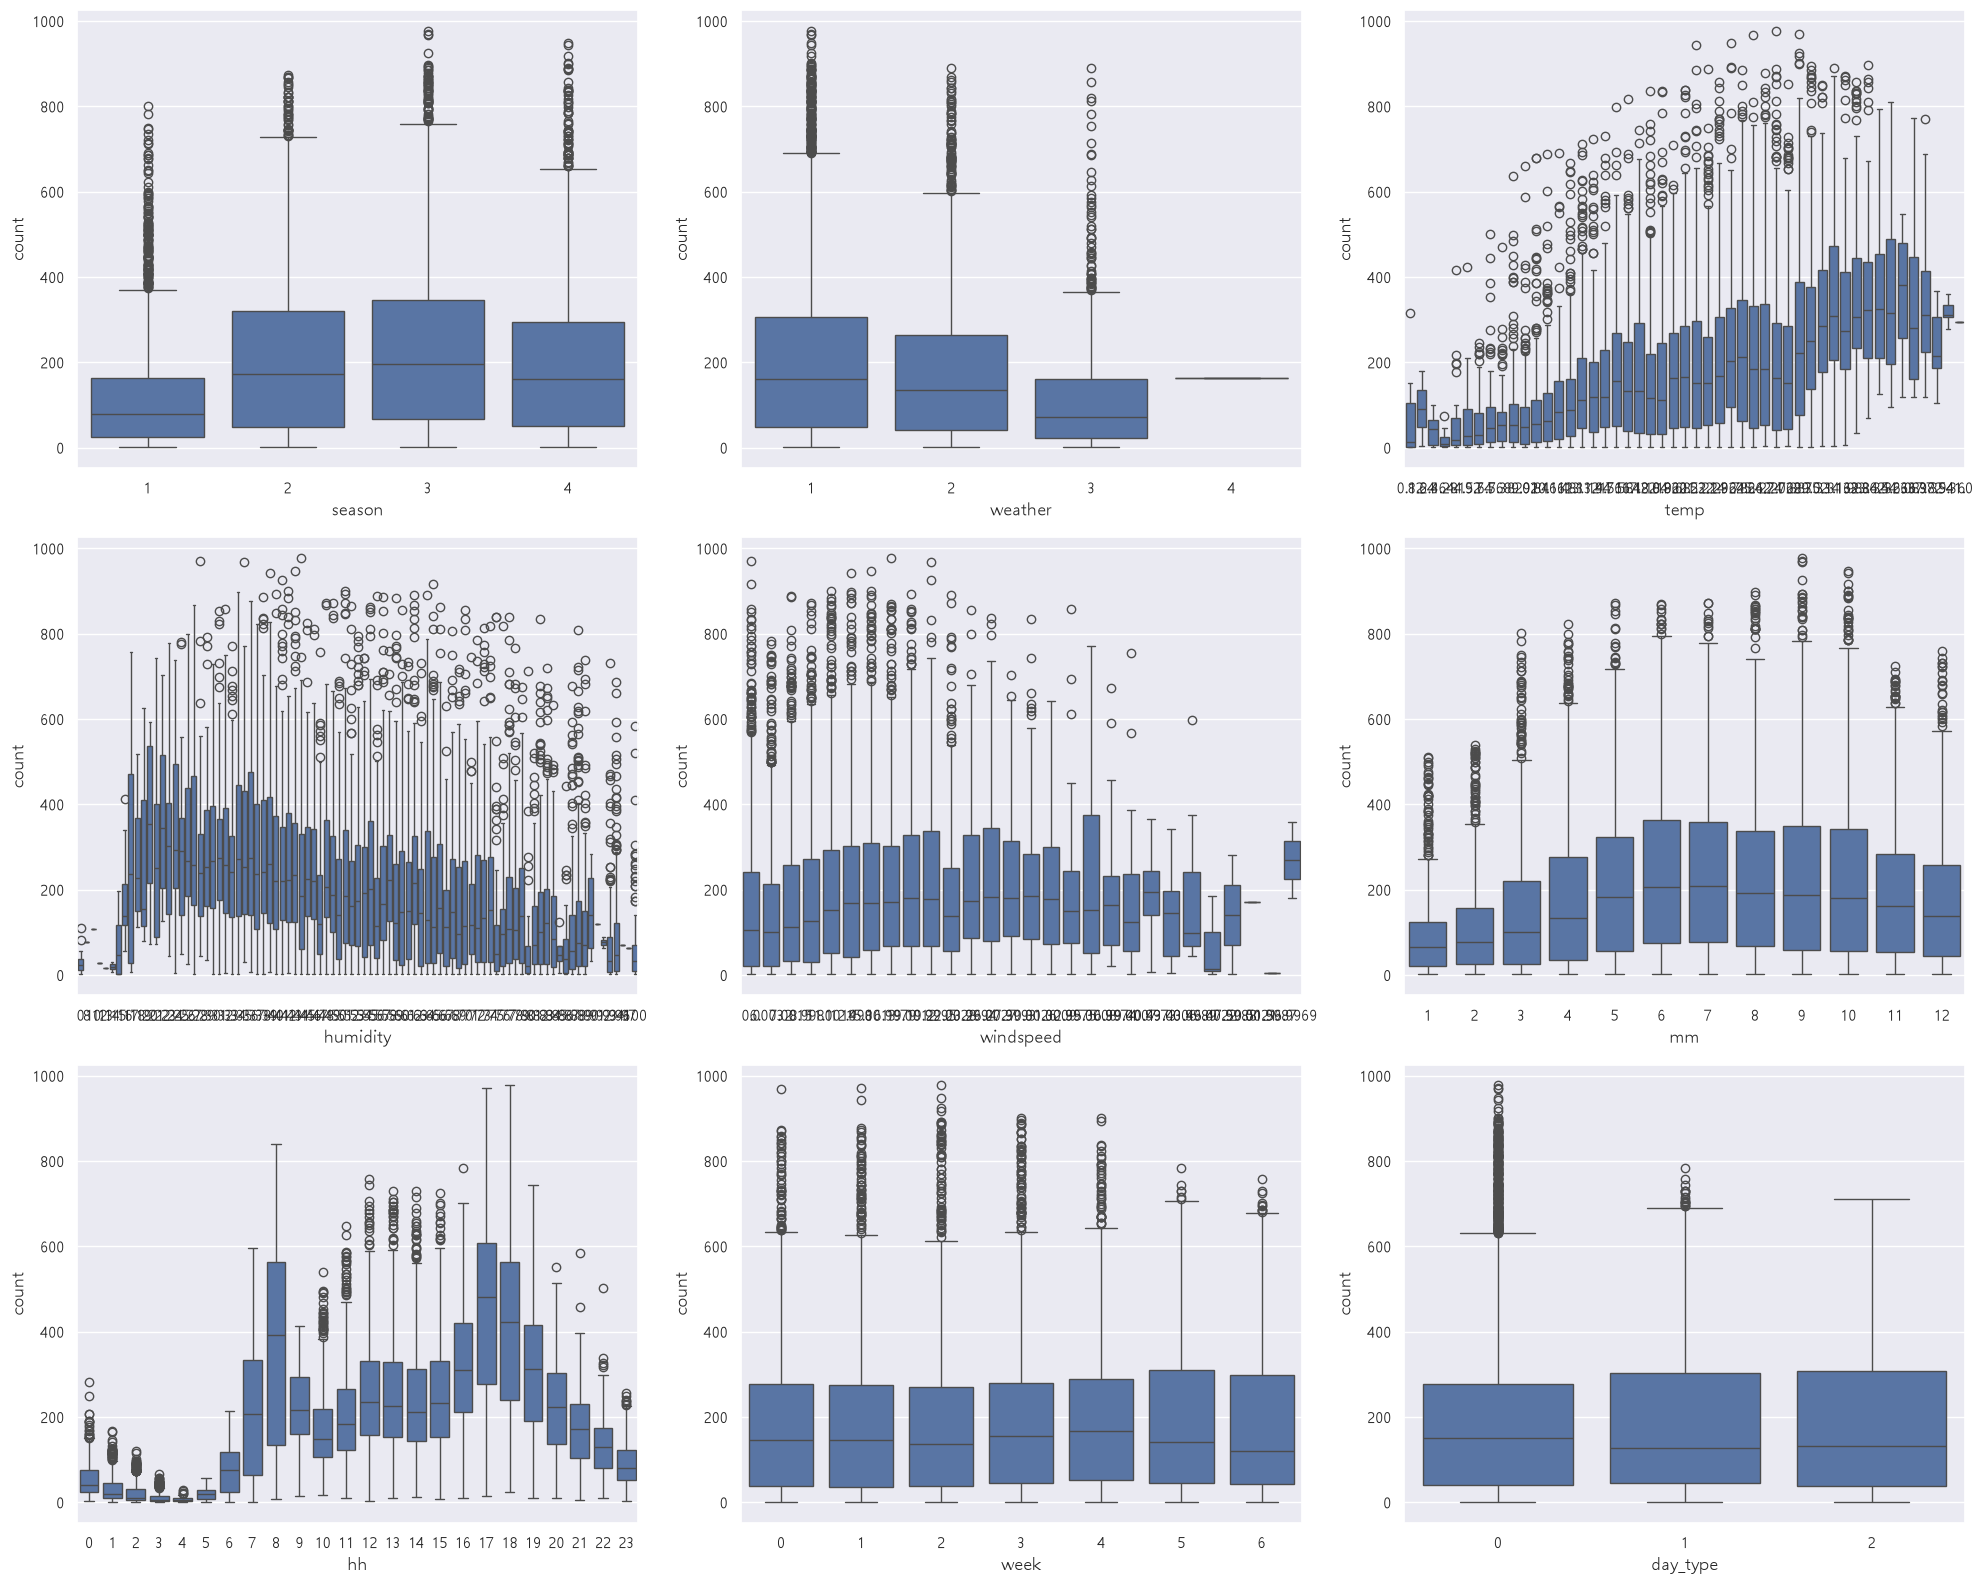

In [46]:
fig, axes = plt.subplots(3,3,     figsize=(20, 16)) 
col_list = ['season','weather', 'temp','humidity', 'windspeed', 'mm','hh', 'week', 'day_type']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.boxplot(x=col, y="count", data=train,  ax=axes[줄][칸])

plt.tight_layout()
plt.show()


### 풍속 0 : 이상치
* 0.0000   :  1313건

In [47]:
train['windspeed'].value_counts()[:5]

windspeed
0.0000     1313
8.9981     1120
11.0014    1057
12.9980    1042
7.0015     1034
Name: count, dtype: int64

In [48]:
test['windspeed'].value_counts()[:5]

windspeed
0.0000     867
11.0014    638
8.9981     618
12.9980    615
7.0015     583
Name: count, dtype: int64

In [49]:
train[train['windspeed'] == 0].head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,0,5,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,5,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,2,5,1


# **[3] 공통함수**

$RMSLE = \sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$

```python 
sklearn.metrics.root_mean_squared_log_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

In [50]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )

In [51]:
#### myscore(X_train7, y_train7, X_test3, y_test3)

In [52]:
def myscore222(df,  model=None, MY_TARGET="count") :
    X = df.drop(columns=['count','registered','casual'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, shuffle=False)

    if model is None : 
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)
    
    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )
    return model

In [53]:
rf = myscore222(train)

RandomForestRegressor
rmsle : 0.3440


In [54]:
train.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,0,5,1


In [55]:
test.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,
2011-01-20,1,0,1,1,10.66,11.365,56,26.0027,2011,1,0,3,0


## **1차점수 : 우선 점수만 보자**
* 0.47781 : 1207등

In [56]:
pred = rf.predict(test)
pred[:10]

array([ 13.21,   5.74,   4.65,   3.43,   2.88,   5.85,  35.51,  95.36,
       208.84, 125.48])

In [57]:
sub['count'] = pred
sub.head()

,datetime,count
0,2011-01-20 00:00:00,13.21
1,2011-01-20 01:00:00,5.74
2,2011-01-20 02:00:00,4.65
3,2011-01-20 03:00:00,3.43
4,2011-01-20 04:00:00,2.88


In [58]:
sub.to_csv("lec11_v01.csv", index=False)

# **[4]전처리 & 가공 : 풍속채우기**
* 이상치

## windspeed 0 처리

* **[1] train_target = train에서 [['count','registered','casual']]만 꺼내놓기**
* **[1] tt = train  + test 합치기**

In [59]:
print(train.shape, test.shape)
train_target = train[['count','registered','casual']]

tt = pd.concat([train, test], axis=0)
print(tt.shape)
tt.head(1)

(10886, 16) (6493, 13)
(17379, 16)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,hh,week,day_type
datetime,,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3.0,13.0,16.0,2011,1,0,5,1


* **[2] train : windspped != 0 /   test = windspped == 0**

In [60]:
tt[tt['windspeed']==0].shape,   tt[tt['windspeed']!=0].shape

((2180, 16), (15199, 16))

In [61]:

tt = tt.drop(columns=['count','registered','casual'])

tt_train = tt[tt['windspeed']!=0]
tt_test  = tt[tt['windspeed']==0]

tt_train_X = tt_train.drop(columns=['windspeed'])
tt_train_y = tt_train['windspeed']

tt_test_X = tt_test.drop(columns=['windspeed'])
tt_test_y = tt_test['windspeed']  #-----------------여기가 풍속이 0 (여길 채워야 함)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=1234
)
rf.fit(tt_train_X, tt_train_y)
pred = rf.predict(tt_test_X)
print(pred[:10])

[ 6.532701  6.512735  6.632732  6.34289   6.22296   6.602515  7.021935
  7.531537 13.660027  7.141731]


* **시리즈에 넣기 : 가로 --> 세로 변형**

In [62]:
re_pred = pred.reshape(-1, 1)
re_pred[:10]

array([[ 6.532701],
       [ 6.512735],
       [ 6.632732],
       [ 6.34289 ],
       [ 6.22296 ],
       [ 6.602515],
       [ 7.021935],
       [ 7.531537],
       [13.660027],
       [ 7.141731]])

In [63]:
print( tt[tt['windspeed']==0].shape )
tt.loc[tt['windspeed']==0   , 'windspeed'] = re_pred
print( tt[tt['windspeed']==0].shape )

(2180, 13)
(0, 13)


In [64]:
train.shape[0], test.shape[0]

train = tt[                : train.shape[0] ]
train = pd.concat([train, train_target], axis=1)

test  = tt[ train.shape[0] :                ]

print( train[train['windspeed']==0].shape )
print( test[test['windspeed']==0].shape )

(0, 16)
(0, 13)


## **2차점수 : 풍속 채운 후 점수**
* 1차 : 0.47781 : 1207등
* 2차 : 0.47739 : 1201등

In [65]:
rf = myscore222(train)

RandomForestRegressor
rmsle : 0.3452


In [66]:
pred = rf.predict(test)
sub['count'] = pred
sub.to_csv("lec11_v02.csv", index=False)

# **[5]전처리 & 가공 : 정규화-스케일링**
* 풍속이 채워진 상태
* 스캐일링
* <font color=red><b>train7 : test3 나눴으면 fit()은 한번만, transform()은 양쪽에

In [67]:
train.shape

(10886, 16)

* <font color=red><b> shuffle=False : 시계열은 데이터를 섞으면 안된다!!!!

In [68]:
X = train.drop(columns=['count','registered','casual'])
y = train['count']
X_train7, X_val3,    y_train7, y_val3 = train_test_split( X, y, test_size=0.3, shuffle=False)

## 원본 점수 : 선형모델, 트리모델

In [69]:
myscore(X_train7, y_train7, X_val3, y_val3)

lasso = Lasso()
myscore(X_train7, y_train7, X_val3, y_val3, lasso)

lidge = Ridge()
myscore(X_train7, y_train7, X_val3, y_val3, lidge)

RandomForestRegressor
rmsle : 0.3452
Lasso
rmsle : 1.2718
Ridge
rmsle : 1.2857


## 스케일링 점수 : 선형모델, 트리모델

In [70]:
#ss = StandardScaler()
#ss = MinMaxScaler()
ss = RobustScaler()
ss.fit(X_train7)
X_train7_scale = ss.transform(X_train7)
X_val3_scale  = ss.transform(X_val3)
#print(X_train7_scale[0])

myscore(X_train7_scale, y_train7, X_val3_scale, y_val3)

lasso = Lasso()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, lasso)

lidge = Ridge()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, lidge)
        

RandomForestRegressor
rmsle : 0.3451
Lasso
rmsle : 1.2717
Ridge
rmsle : 1.2859


## 모델학습 후 피쳐 중요도

* <b>트리모델 : model.feature_importances_

RandomForestRegressor
rmsle : 0.3452
[0.00719681 0.001326   0.01895349 0.01586262 0.06841841 0.07685319
 0.04007553 0.01266726 0.05396807 0.03815206 0.60722195 0.03995056
 0.01935403]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


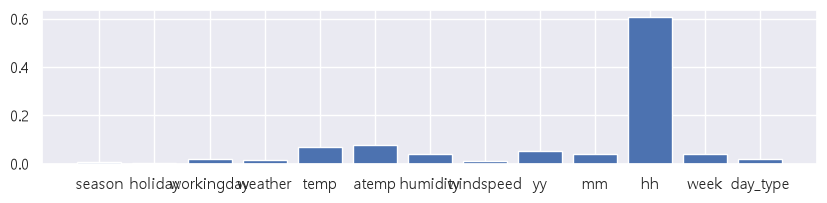

In [71]:
rf = myscore222(train)
imp = rf.feature_importances_
print(imp)
print(X_train7.columns)


plt.figure(figsize=(10, 2)) 
plt.bar(X_train7.columns, imp)
plt.show()


* <b>선형모델 : model.coef_  (회귀계수==기울기==가중치==중요도)

Ridge
rmsle : 1.2857
[ 3.22710188 -3.33323674 -1.63522323 -8.67888022 -1.86149919  8.0041822
 -1.44437771  0.54011295 85.66138738  5.50154094  6.47579107  1.54762632
 -1.69801351]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


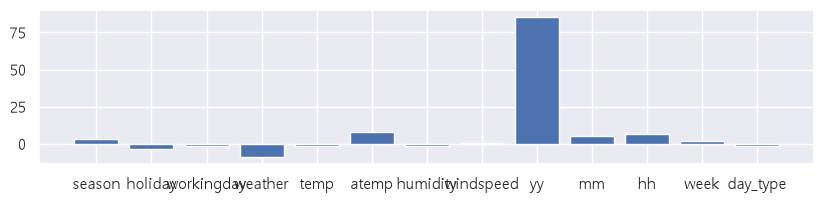

In [72]:
lidge = Ridge()
model = myscore222(train, lidge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar(X_train7.columns, imp)
plt.show()

* <b>선형모델 : model.coef_  (회귀계수==기울기==가중치==중요도)

Lasso
rmsle : 1.2718
[ 0.         -0.         -0.         -5.62884455 -0.          6.32376964
 -1.49869547  0.38898873 79.16123026  6.05051491  6.42237285  1.33930431
 -0.        ]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


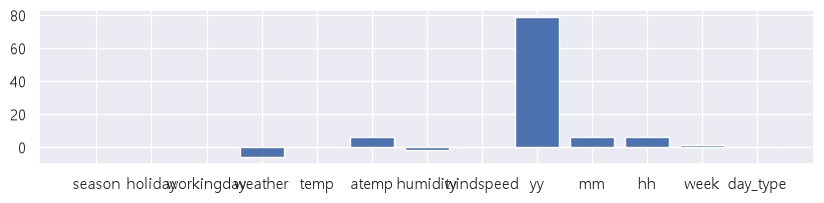

In [73]:
lasso = Lasso()
model = myscore222(train, lasso)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar(X_train7.columns, imp)
plt.show()

## 선형 모델은 무조건 yy 가 중요???

### yy 값 1,2로 변경

In [74]:
train['yy'].value_counts()

yy
2012    5464
2011    5422
Name: count, dtype: int64

In [75]:
train['yy'] = train['yy'].map({2011: 1, 2012: 2})
#train['yy'] = train['yy'].apply(lambda x: 1 if x == 2011 else 2)

test['yy'] = test['yy'].map({2011: 1, 2012: 2})

In [76]:
train.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,hh,week,day_type,count,registered,casual
datetime,,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,6.532701,1,1,0,5,1,16,13,3


Ridge
rmsle : 1.2857
[ 3.22710188 -3.33323674 -1.63522323 -8.67888022 -1.86149919  8.0041822
 -1.44437771  0.54011295 85.66138738  5.50154094  6.47579107  1.54762632
 -1.69801351]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


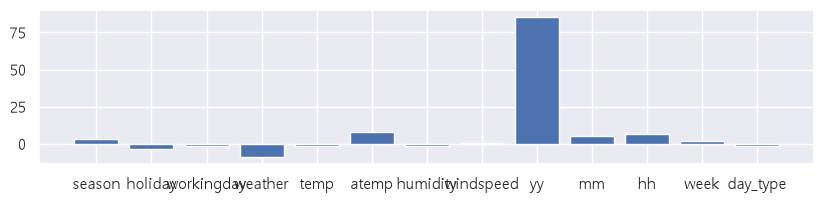

In [77]:
lidge = Ridge()
model = myscore222(train, lidge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar(X_train7.columns, imp)
plt.show()

### yy 삭제 

In [78]:
traincp = train.copy()
traincp = traincp.drop(columns=['yy'])
traincp.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,mm,hh,week,day_type,count,registered,casual
datetime,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,6.532701,1,0,5,1,16,13,3


Ridge
rmsle : 1.1372
[ 2.55231803  0.30578457  0.61088712 -7.12581382 -4.87989495 10.75461916
 -1.61201156  0.4927753   0.43553547  6.34203399  1.68510205 -0.30510255]
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'yy', 'mm', 'hh', 'week', 'day_type'],
      dtype='str')


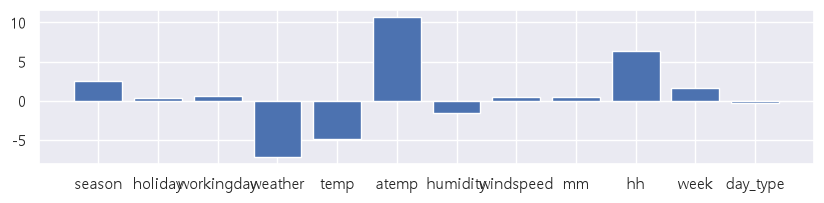

In [79]:
lidge = Ridge()
model = myscore222(traincp, lidge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp)
plt.show()

# **[6]전처리 & 가공 : 정규화-규제**
* 모델교체
* 풍속이 채워진 상태
* 규제

<b>Lec05 참조 (BostonHousePrice)

# **[7] 강력한 모델로 교체**
* 선형 보다는 트리 모델이 좋은 성능을 보임
* pip install xgboost , lightgbm

## **XGBoost**
* XGBoost(Extreme Gradient Boosting)는 정형(표 형태) 데이터 예측에서 뛰어난 성능과 빠른 속도를 보여주는 그레이디언트 부스팅(Gradient Boosting) 기반의 오픈소스 머신러닝 라이브러리

XGBRegressor
rmsle : 0.5984


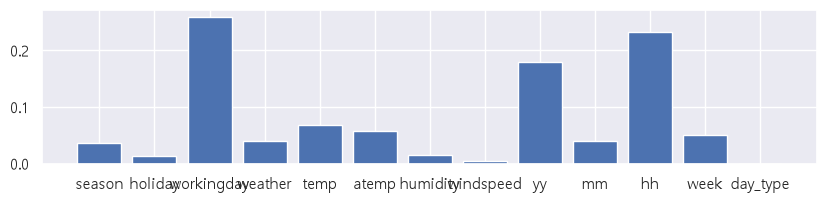

In [80]:
# import xgboost as xgb
# model = xgb.XGBRegressor()

from xgboost import XGBRegressor, XGBClassifier 
xgb = XGBRegressor()

model = myscore222(train, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar( X_train7.columns, imp)
plt.show()


XGBRegressor
rmsle : 0.6317


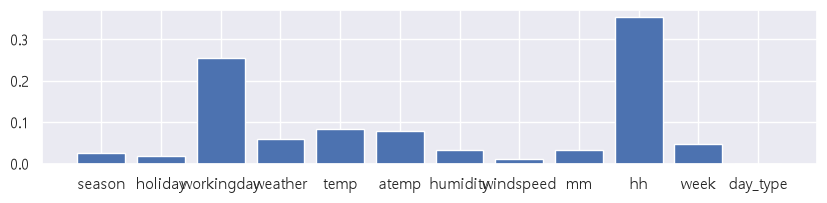

In [81]:
xgb = XGBRegressor()
model = myscore222(traincp, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp)
plt.show()

## **LightGBM**
* LightGBM(Light Gradient Boosting Machine)은 마이크로소프트에서 개발한 빠르고 효율적인 트리 기반의 오픈소스 머신러닝 라이브러리

LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 13
[LightGBM] [Info] Start training from score 159.125459
rmsle : 0.4284


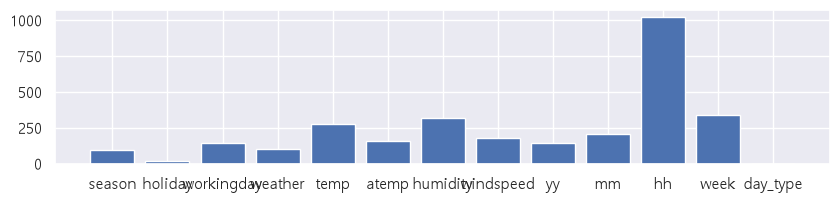

In [82]:
from lightgbm import LGBMRegressor, LGBMClassifier 
lgb = LGBMRegressor()

model = myscore222(train, lgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar( X_train7.columns, imp)
plt.show()

## **3차점수 : 풍속 채우기 + 모델교체 후 점수**
* 1차 : 0.47781 : 1207등
* 2차 : 0.47739 : 1201등
* 3차 : 0.52408

In [83]:
lgb = LGBMRegressor()
model = myscore222(train, lgb)
pred = model.predict(test)
pred = np.maximum(pred, 0)
sub['count'] = pred
sub.to_csv("lec11_v03.csv", index=False)

LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 13
[LightGBM] [Info] Start training from score 159.125459
rmsle : 0.4284


# **[8] casual + registered**
* 각각 예측해서 합산

In [84]:
# 0.5564
rf = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
model= myscore222(train,  rf,  MY_TARGET="casual")
pred_c = model.predict(test)
pred_c = np.maximum(pred_c, 0)
print(pred_c[:10])

RandomForestRegressor
rmsle : 0.5499
[1.56  0.87  1.005 0.405 0.38  0.23  2.03  3.26  8.35  6.69 ]


In [85]:
rf = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
model= myscore222(train,  rf,  MY_TARGET="registered")
pred_r = model.predict(test)
pred_r = np.maximum(pred_r, 0)
print(pred_r[:10])

RandomForestRegressor
rmsle : 0.3528
[ 10.73   5.35   3.14   2.28   2.03   6.08  35.03  86.57 213.3  122.48]


## count = casual + registered
* 747등 : 0.43969
* 3244 / 747 (23%)

In [86]:
count = pred_c + pred_r
print(count)

[ 12.29    6.22    4.145 ... 103.87  105.     51.59 ]


In [87]:
count = np.maximum(count, 0)
sub['count'] = count
sub.to_csv("lec11_v04.csv", index=False)

## count 가중 = casual + registered
* 0.64695

In [88]:
0.5714 / (0.5714 + 0.3528)

0.6182644449253408

In [89]:
1 - 0.618

0.382

In [90]:
count = (pred_c *0.382) + (pred_r*0.618)
print(count)

[ 7.22706  3.63864  2.32443 ... 63.1627  64.0404  31.18406]


In [91]:
count = np.maximum(count, 0)
sub['count'] = count
sub.to_csv("lec11_v05.csv", index=False)